<a href="https://colab.research.google.com/github/yohan2330/pca_assignment/blob/main/Template_PCA_Formative_1%5BPeer_Pair_Number%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

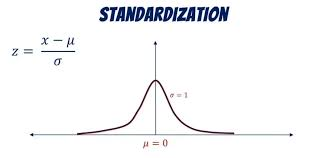


In [4]:
import numpy as np
import csv

filepath = 'Data/Life Expectancy Data.csv'   

african_countries = {
    'Algeria','Angola','Benin','Botswana','Burkina Faso','Burundi',
    'Cabo Verde','Cameroon','Central African Republic','Chad','Comoros',
    'Congo',"Côte d'Ivoire",'Democratic Republic of the Congo',
    'Djibouti','Egypt','Equatorial Guinea','Eritrea','Ethiopia',
    'Gabon','Gambia','Ghana','Guinea','Guinea-Bissau','Kenya','Lesotho',
    'Liberia','Libya','Madagascar','Malawi','Mali','Mauritania','Mauritius',
    'Morocco','Mozambique','Namibia','Niger','Nigeria','Rwanda',
    'Sao Tome and Principe','Senegal','Seychelles','Sierra Leone','Somalia',
    'South Africa','South Sudan','Sudan','Swaziland','Togo','Tunisia',
    'Uganda','United Republic of Tanzania','Zambia','Zimbabwe'
}

numeric_col_names = [
    'Life expectancy ',      # espace à la fin
    'Adult Mortality',
    'infant deaths',
    'percentage expenditure',
    'Measles ',              # espace à la fin
    'under-five deaths ',    # espace à la fin
    ' HIV/AIDS',             # espace avant
    'Schooling'
]

missing_counts = {col: 0 for col in numeric_col_names}
total_african = 0

with open(filepath, encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row.get('Country') not in african_countries:
            continue
        total_african += 1
        for col in numeric_col_names:
            val = row.get(col, '').strip()
            if val == '' or val.lower() == 'nan':
                missing_counts[col] += 1

print(f"Total African rows found: {total_african}")
print("\nMissing values per column (BEFORE cleaning):")
for col, count in missing_counts.items():
    print(f"  {col.strip():<35} {count} missing")

rows = []
country_col = []
status_col = []

with open(filepath, encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row.get('Country') not in african_countries:
            continue
            
        values = []
        for col in numeric_col_names:
            val = row.get(col, '').strip()
            if val == '' or val.lower() == 'nan':
                values.append(np.nan)
            else:
                values.append(float(val))
        
        rows.append(values)
        country_col.append(row['Country'])
        status_col.append(row['Status'])

X = np.array(rows, dtype=float)
country_col = np.array(country_col)
status_col = np.array(status_col)

print(f"\nData shape after loading: {X.shape}")

# Imputation of the NaN 
col_means = np.nanmean(X, axis=0)
for j in range(X.shape[1]):
    mask = np.isnan(X[:, j])
    X[mask, j] = col_means[j]

print("Any NaNs remaining?", np.isnan(X).any())

means = np.mean(X, axis=0)
stds = np.std(X, axis=0)
standardized_data = (X - means) / stds

print('\nStandardization check:')
print('Means:', np.round(np.mean(standardized_data, axis=0), 6))
print('Stds :', np.round(np.std(standardized_data, axis=0), 6))

Total African rows found: 864

Missing values per column (BEFORE cleaning):
  Life expectancy                     0 missing
  Adult Mortality                     0 missing
  infant deaths                       0 missing
  percentage expenditure              0 missing
  Measles                             0 missing
  under-five deaths                   0 missing
  HIV/AIDS                            0 missing
  Schooling                           64 missing

Data shape after loading: (864, 8)
Any NaNs remaining? False

Standardization check:
Means: [0. 0. 0. 0. 0. 0. 0. 0.]
Stds : [1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [5]:
# Covariance: C = (1 / n-1) * X^T @ X
n = standardized_data.shape[0]
cov_matrix = (1 / (n - 1)) * (standardized_data.T @ standardized_data)

print('Covariance Matrix shape:', cov_matrix.shape)
print()
print(np.round(cov_matrix, 3))


Covariance Matrix shape: (8, 8)

[[ 1.001 -0.495 -0.243  0.256 -0.155 -0.259 -0.518  0.496]
 [-0.495  1.001  0.033 -0.015 -0.044  0.033  0.449 -0.115]
 [-0.243  0.033  1.001 -0.127  0.528  0.999 -0.033 -0.127]
 [ 0.256 -0.015 -0.127  1.001 -0.085 -0.127  0.083  0.383]
 [-0.155 -0.044  0.528 -0.085  1.001  0.529 -0.019 -0.084]
 [-0.259  0.033  0.999 -0.127  0.529  1.001 -0.029 -0.147]
 [-0.518  0.449 -0.033  0.083 -0.019 -0.029  1.001  0.091]
 [ 0.496 -0.115 -0.127  0.383 -0.084 -0.147  0.091  1.001]]


In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

The covariance matrix reveals linear relationships between all pairs of health features. First, features like infant deaths and under-five deaths have very high covariance they carry nearly the same information, so PCA can compress them into one component. Second, the eigenvectors of the covariance matrix point in the directions of maximum variance these are the principal components that reduce dimensions while retaining as much information as possible.


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [6]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Keep real parts only
eigenvalues  = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

print('Eigenvalues:')
print(np.round(eigenvalues, 4))
print()
print('Sum of eigenvalues (should = 8):', round(np.sum(eigenvalues), 4))

Eigenvalues:
[2.6960e+00 1.9350e+00 1.3689e+00 2.3000e-03 2.1340e-01 5.2380e-01
 6.1860e-01 6.5130e-01]

Sum of eigenvalues (should = 8): 8.0093


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [7]:
# Step 5: Sort Principal Components in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues  = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance      = np.cumsum(explained_variance_ratio)

print(f"{'PC':<5} {'Eigenvalue':>12} {'Variance %':>12} {'Cumulative %':>14}")
print('-' * 46)
for i in range(len(sorted_eigenvalues)):
    print(f"PC{i+1:<3} "
          f"{sorted_eigenvalues[i]:>12.4f} "
          f"{explained_variance_ratio[i]*100:>11.2f}% "
          f"{cumulative_variance[i]*100:>13.2f}%")

PC      Eigenvalue   Variance %   Cumulative %
----------------------------------------------
PC1         2.6960       33.66%         33.66%
PC2         1.9350       24.16%         57.82%
PC3         1.3689       17.09%         74.91%
PC4         0.6513        8.13%         83.04%
PC5         0.6186        7.72%         90.77%
PC6         0.5238        6.54%         97.31%
PC7         0.2134        2.66%         99.97%
PC8         0.0023        0.03%        100.00%


Explanation variance provides us with an indication about how much information does the principal component hold about the entire variance in the dataset. For the PCA, eigenvalues have to be normalized into percentages by dividing the individual eigenvalue with the sum of all eigenvalues. The normalized values will later be summed up and presented in the form of a cumulative variance plot, used for determining the number of components to be retained.

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [8]:
# Step 6: Project Data onto Principal Components

num_components = np.argmax(cumulative_variance >= 0.95) + 1

reduced_data = np.dot(
    standardized_data,
    sorted_eigenvectors[:, :num_components]
)

reduced_data[:5]

array([[-1.98370493,  2.18788518,  0.18482782,  1.45185828,  0.59672385,
         0.19083541],
       [-2.03828809,  2.21829009,  0.32379011,  1.2814786 ,  0.49791932,
         0.25771271],
       [-2.40706981,  2.04037406,  1.83307208, -0.42372601, -0.01647341,
         0.00421351],
       [-2.40785184,  2.02890773,  1.86482881, -0.46402024, -0.0352848 ,
         0.01029938],
       [-2.3079533 ,  1.96792437,  1.65290013, -0.38534861, -0.00751125,
        -0.00801639]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [9]:
# Step 7: Output the Reduced Data

print(f"Reduced Data Shape: {reduced_data.shape}")

print("\nFirst 5 rows of reduced data:")
print(np.round(reduced_data[:5], 4))

Reduced Data Shape: (864, 6)

First 5 rows of reduced data:
[[-1.9837  2.1879  0.1848  1.4519  0.5967  0.1908]
 [-2.0383  2.2183  0.3238  1.2815  0.4979  0.2577]
 [-2.4071  2.0404  1.8331 -0.4237 -0.0165  0.0042]
 [-2.4079  2.0289  1.8648 -0.464  -0.0353  0.0103]
 [-2.308   1.9679  1.6529 -0.3853 -0.0075 -0.008 ]]


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

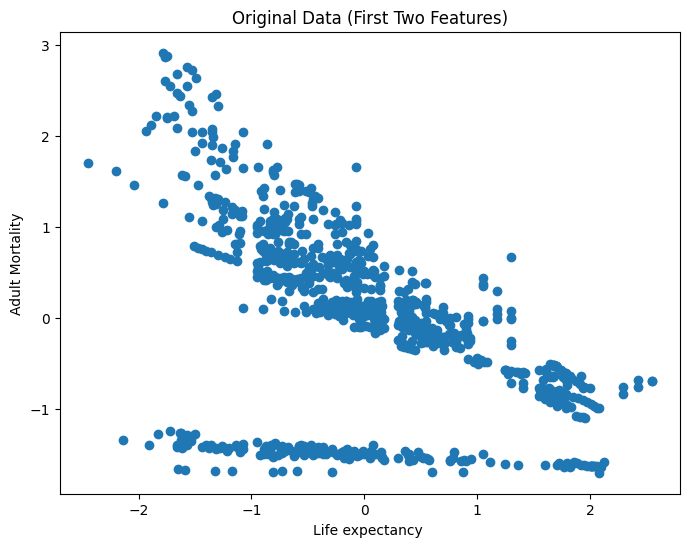

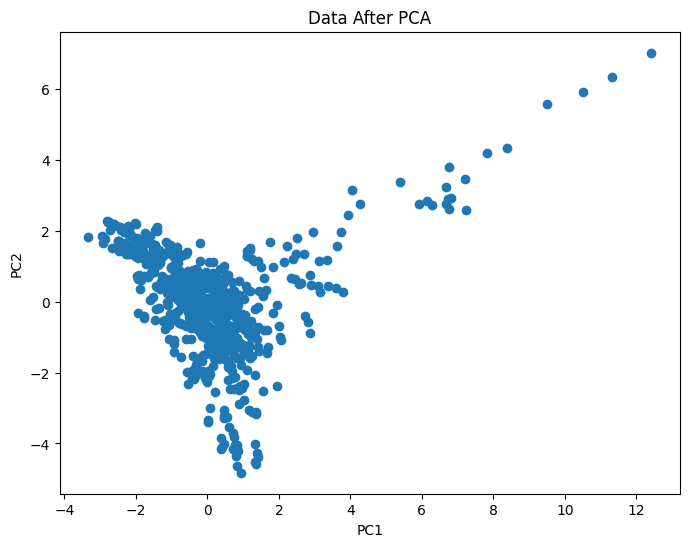

In [10]:
# Step 8: Visualize Before and After PCA

import matplotlib.pyplot as plt

# Plot original data (first two features for simplicity)

plt.figure(figsize=(8,6))
plt.scatter(
    standardized_data[:, 0],
    standardized_data[:, 1]
)
plt.title("Original Data (First Two Features)")
plt.xlabel(numeric_col_names[0])
plt.ylabel(numeric_col_names[1])
plt.show()


# Plot reduced data after PCA

plt.figure(figsize=(8,6))
plt.scatter(
    reduced_data[:, 0],
    reduced_data[:, 1]
)
plt.title("Data After PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


1. Interpret the visual:

The first plot shows the original standardized data along two raw features Life Expectancy and Adult Mortality which are only two of the 8 features in the dataset. The second plot shows the same [your actual row number] data points projected onto PC1 and PC2, which are no longer single features but linear combinations of all 8 features. The data in the PCA plot is centred at the origin and the horizontal spread along PC1 is visibly wider than the vertical spread along PC2, confirming that PC1 captures the most variance. The overall structure of the data is preserved — clusters and outliers remain visible but the axes now represent the directions of maximum variance across all features simultaneously, rather than any single measurement.

2. The set of factors selected was that which could account for more than 95% of the variability in the data as shown from the point on the graph where the cumulative percentage of explained variance intersects the 95% level. However, the problem that arises with this approach is that 5% of the variability in the eliminated components will not be taken into consideration. This simplifies analysis and visualization of the dataset, but also leads to a loss of some minor country-level differences.

3. What information is lost:

Reducing from 8 features to fewer principal components means fine-grained variation in indicators like Measles cases, percentage health expenditure, and HIV/AIDS rates signals of population pressure and economic activity unique to specific African countries is discarded. Country level nuances such as how health expenditure in a given year correlates with adult mortality are averaged out, meaning the reduced data cannot fully reconstruct original disease burden or schooling estimates for individual countries.